# Binomial distribution

---

#### Summary videos

- [Binomial distribution: finding probabilities](https://youtu.be/tKmyzhvgudw?si=X8-IZwjBtHNrhQ7o) (9 minutes)
- [Binomial distribution: probabilities of probabilities](https://youtu.be/8idr1WZ1A7Q?si=lw-laoBy8hS2MfXs) (13 minutes)

#### Walkthrough videos

- [The geometric distribution](https://drive.google.com/file/d/1kE5Sd566uyk3FkTNHQfANkYhhpeA6xpQ/view?usp=sharing) (12 minutes)
- [The binomial distribution](https://drive.google.com/file/d/1KLN7Mt1Eg2UaMXn-WOpUTmmXIzgnWb5u/view?usp=sharing) (11 minutes)
- [Normal approximations to the binomial distribution](https://drive.google.com/file/d/1OGSP2tFqlwNsqEVM3g6QGnxisPpXH4bj/view?usp=sharing) (15 minutes)

---

## Bernoulli variables and the geometric distribution

A random variable with only two possible outcomes (often called `success` and `failure`) is called a **Bernoulli random variable**. Flipping a coin is an example, where we might consider `heads` to be `success` and `tails` to be `failure`.

### Question

Suppose we have a fair coin.

* What is the probability that we observe `heads` on the first toss?
* What is the probability that we observe `tails` on the first toss and `heads` on the second toss?
* What is the probability that we observe `heads` for the first time on the third toss?
* What is the probability that we observe `heads` for the first time on the $n$-th toss?
* How many flips will it take to guarantee that we observe a `heads`?

Let's simulate the situtation to test our conjecture.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from plotnine import *

The function `coinToss` will simulate tossing a coin `n` times with probability of observing heads on the first toss as 0.5.

In [ ]:
coin_flip_outcomes = ['heads', 'tails']

def coinToss(n, prob_success):
  return np.random.choice(coin_flip_outcomes, size = n, p = [prob_success, 1 - prob_success])

In [ ]:
coinToss(6, 0.5)

Now, we'll simulate tossing a fair coin 6 times and repeat those 6 trials 100 times. Then `success_counts` counts how many times we observed `heads` on the first try, second try, third try etc.

In [ ]:
results = []
for i in range(100):
  results.append(coinToss(6, 0.5).tolist())

successes = []
for result in results:
  if result[0] == 'heads':
    successes.append('1st try!')
  elif result[1] == 'heads':
    successes.append('2nd try!')
  elif result[2] == 'heads':
    successes.append('3rd try!')
  elif result[3] == 'heads':
    successes.append('4th try!')
  elif result[4] == 'heads':
    successes.append('5th try!')
  elif result[5] == 'heads':
    successes.append('6th try!')

success_counts = [successes.count('1st try!'), successes.count('2nd try!'),
                  successes.count('3rd try!'), successes.count('4th try!'),
                  successes.count('5th try!'), successes.count('6th try!')]

success_counts

Finally, we can make a bar plot!

In [ ]:
plot_df = pd.DataFrame({'tries' : ['1st try!', '2nd try!', '3rd try!', '4th try!', '5th try!', 'sixth try!'], 'counts' : success_counts})

(
    ggplot(plot_df) +
    aes(x = 'tries', y = 'counts') +
    geom_bar(stat = 'identity')
)

This bar plot is an approximation of the **geometric distribution** with probability of success $p = 0.5$. We see that, under these conditions, we can be fairly certain of observing a heads within 6 tosses of a fair coin.

Let's repeat our simulation with an unfair coin that lands `heads` 70% of the time.

In [ ]:
results = []
for i in range(100):
  results.append(coinToss(6, 0.7).tolist())

successes = []
for result in results:
  if result[0] == 'heads':
    successes.append('1st try!')
  elif result[1] == 'heads':
    successes.append('2nd try!')
  elif result[2] == 'heads':
    successes.append('3rd try!')
  elif result[3] == 'heads':
    successes.append('4th try!')
  elif result[4] == 'heads':
    successes.append('5th try!')
  elif result[5] == 'heads':
    successes.append('6th try!')

success_counts = [successes.count('1st try!'), successes.count('2nd try!'),
                  successes.count('3rd try!'), successes.count('4th try!'),
                  successes.count('5th try!'), successes.count('6th try!')]

(
    ggplot(pd.DataFrame({'tries' : ['1st try!', '2nd try!', '3rd try!', '4th try!', '5th try!', 'sixth try!'], 'counts' : success_counts})) +
    aes(x = 'tries', y = 'counts') +
    geom_bar(stat = 'identity')
)

This bar plot approximates a geometric distribution with $p = 0.7$. Notice, it takes fewer tosses for this coin to turn up heads with a reasonable amount of certainty because on this unfair coin, `heads` is more likely to turn up than `tails`.

In general, for a Bernoulli variable with probability of successs $p$ and probability of failure $1 - p$, the probability of observing a success for the first time on the $n$-th trial is

$$(1 - p)^{n-1} \cdot p.$$

Below is a summary of Bernoulli random variables and the geometric distribution from page 144 and 146 of the textbook, respectively.

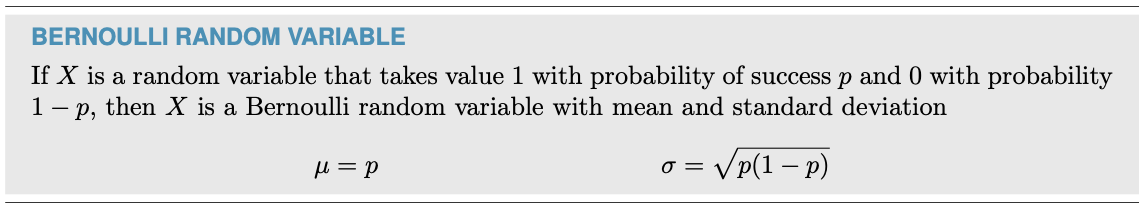

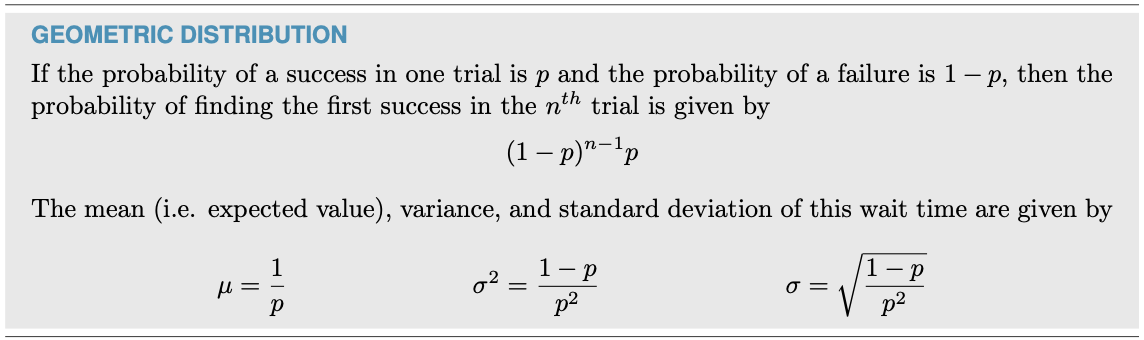

## The binomial distribution

### Questions

Suppose we toss a fair coin 10 times.

* How many `heads` would you expect to observe?
* What is the probability that the first 3 outcomes are `heads` and the rest are `tails`?
* How many of the possible outcomes contain exactly 3 `heads`?
* What is the probability of observing 3 `heads` in any order?

### Some notation

* $n! = n \cdot (n-1) \cdot (n-2) \cdot \cdots \cdot 3 \cdot 2 \cdot 1$
  * This is called a *factorial* and it counts the number of ways to rearrange a list of $n$ items.
* ${n \choose k} = \dfrac{n!}{k!(n-k)!}$
  * This is read "$n$ choose $k$" and it counts the number of ways to select $k$ things from a group of $n$ things (if order doesn't matter).

The code below runs a simulation of tossing a fair coin 10 times and recording whether there are $k$ `heads` observed — this process is repeated 10,000 times for $k$ between 0 and 10.

In [ ]:
binomial_results = []
for i in range(10000):
  binomial_results.append(coinToss(10, 0.5).tolist())

head_counts = []
for binomial_result in binomial_results:
  head_counts.append(binomial_result.count('heads'))

(
    ggplot(pd.DataFrame(head_counts)) +
    aes(x = 'head_counts') +
    geom_histogram(binwidth = 1)
)

This is called a **binomial distribution**. Does it look familiar?

## Normal approximations to the binomial distribution

Here are the details on regarding the binomial distribution from page 150 of the textbook.

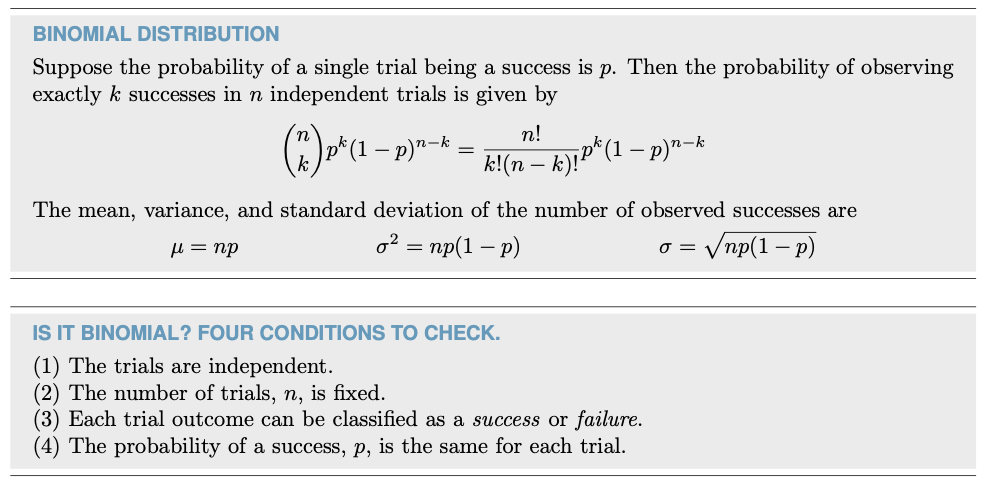

### Exercise
Consider a Bernoulli variable with probability of success 0.65.

* What is the  probability of observing 4 successes out of 12 trials.
* What is the expected number of successes out of 12 trials?
* What about the standard deviation?

### Example 4.38 (page 154)
Approximately 15% of the US population smokes cigarettes. A local government believed their community had a lower smoker rate and commissioned a survey of 400 randomly selected individuals.

The survey found that only 42 of the 400 participants smoke cigarettes.

If the true proportion of smokers in the community was really 15% (the national average), what is the probability of observing 42 or fewer smokers in a sample of 400 people?

In [ ]:
from scipy.stats import binom

n = 400
p = 0.15

sum(
  [binom.pmf(k, n, p) for k in range(43)]
)

Computing binomial probabilities can be tedious, so sometimes using the normal distribution as an approximations is helpful! As we saw above, with a sufficiently large number of trials $n$, the binomial distribution is nearly normal (as described on page 153 of the textbook).

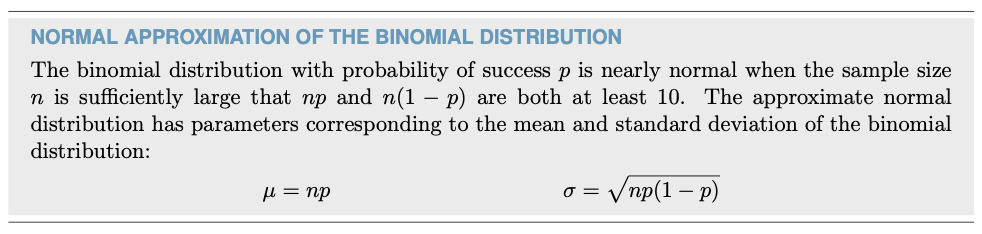

### Question

- Refer to the example above. Use a [normal distribution](https://www.geogebra.org/classic#probability) to approximate the probability of observing 42 or fewer smokers from the sample.
- How far off is this estimate from the exact probability calculated earlier?

---

This notebook was written by Timothy L. Clark, derivative of [OpenIntro Statistics by Diez, Çetinkaya-Rundel, and Barr](https://www.openintro.org/book/os/), released under [Creative Commons BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/deed.en) license.